# Notebook 01 — Teste do módulo `constants.py`

Este notebook testa o primeiro módulo da pasta **`geodesy/`**:

```python
geodesy/constants.py
```

O objetivo é verificar:

- importação correta do pacote `geodesy`;
- constantes físicas e geodésicas;
- parâmetros dos elipsoides WGS84 e GRS80;
- classe `Ellipsoid`;
- função `get_ellipsoid`;
- conversões básicas de unidade;
- comparações gráficas entre parâmetros dos elipsoides.


In [1]:
# ============================================================
# 0. CONFIGURAÇÃO INICIAL
# ============================================================

import os
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

# Este notebook assume que a pasta "geodesy" está no mesmo diretório do notebook.
# Se estiver em outro diretório, ajuste o caminho abaixo.
current_dir = Path.cwd()

if (current_dir / "geodesy").exists():
    sys.path.insert(0, str(current_dir))
    print("Pasta geodesy encontrada no diretório atual.")
else:
    print("Atenção: a pasta geodesy não foi encontrada no diretório atual.")
    print("Coloque este notebook na mesma pasta onde está a pasta geodesy/.")

import geodesy
from geodesy import constants

print("Versão do pacote geodesy:", geodesy.__version__)


Pasta geodesy encontrada no diretório atual.
Versão do pacote geodesy: 0.1.0


## 1. Verificação das constantes físicas principais

Aqui vamos imprimir as constantes físicas e geodésicas definidas em `constants.py`.


In [2]:
# ============================================================
# 1. CONSTANTES FÍSICAS E GEODÉSICAS
# ============================================================

print("Constante gravitacional universal G:")
print(constants.G_CONSTANT, "m³ kg⁻¹ s⁻²")

print("\nVelocidade da luz:")
print(constants.SPEED_OF_LIGHT, "m/s")

print("\nRaio médio da Terra:")
print(constants.MEAN_EARTH_RADIUS, "m")

print("\nMassa aproximada da Terra:")
print(constants.EARTH_MASS, "kg")

print("\nConversão grau-radiano:")
print("DEG2RAD =", constants.DEG2RAD)
print("RAD2DEG =", constants.RAD2DEG)

print("\nConversão mGal <-> SI:")
print("MGAL_TO_SI =", constants.MGAL_TO_SI)
print("SI_TO_MGAL =", constants.SI_TO_MGAL)


Constante gravitacional universal G:
6.6743e-11 m³ kg⁻¹ s⁻²

Velocidade da luz:
299792458.0 m/s

Raio médio da Terra:
6371008.8 m

Massa aproximada da Terra:
5.9722e+24 kg

Conversão grau-radiano:
DEG2RAD = 0.017453292519943295
RAD2DEG = 57.29577951308232

Conversão mGal <-> SI:
MGAL_TO_SI = 1e-05
SI_TO_MGAL = 100000.0


## 2. Parâmetros WGS84

O WGS84 é um dos elipsoides de referência mais usados em GNSS e geodésia global.


In [3]:
# ============================================================
# 2. PARÂMETROS WGS84
# ============================================================

print("WGS84_A:", constants.WGS84_A)
print("WGS84_F:", constants.WGS84_F)
print("WGS84_GM:", constants.WGS84_GM)
print("WGS84_OMEGA:", constants.WGS84_OMEGA)

print("\nGravidade normal no Equador:")
print(constants.GAMMA_E_WGS84, "m/s²")

print("\nGravidade normal no Polo:")
print(constants.GAMMA_P_WGS84, "m/s²")

print("\nConstante k de Somigliana:")
print(constants.K_SOMIGLIANA_WGS84)


WGS84_A: 6378137.0
WGS84_F: 0.0033528106647474805
WGS84_GM: 398600441800000.0
WGS84_OMEGA: 7.292115e-05

Gravidade normal no Equador:
9.7803253359 m/s²

Gravidade normal no Polo:
9.8321849378 m/s²

Constante k de Somigliana:
0.00193185265241


## 3. Parâmetros GRS80

O GRS80 é outro sistema de referência importante, muito próximo do WGS84.


In [4]:
# ============================================================
# 3. PARÂMETROS GRS80
# ============================================================

print("GRS80_A:", constants.GRS80_A)
print("GRS80_F:", constants.GRS80_F)
print("GRS80_GM:", constants.GRS80_GM)
print("GRS80_OMEGA:", constants.GRS80_OMEGA)


GRS80_A: 6378137.0
GRS80_F: 0.003352810681182319
GRS80_GM: 398600500000000.0
GRS80_OMEGA: 7.292115e-05


## 4. Teste da classe `Ellipsoid`

Agora vamos acessar diretamente os objetos `WGS84` e `GRS80`, que foram definidos como instâncias da classe `Ellipsoid`.


In [5]:
# ============================================================
# 4. TESTE DA CLASSE Ellipsoid
# ============================================================

wgs84 = constants.WGS84
grs80 = constants.GRS80

print("Objeto WGS84:")
print(wgs84)

print("\nObjeto GRS80:")
print(grs80)

print("\nParâmetros derivados do WGS84:")
print("Nome:", wgs84.name)
print("a:", wgs84.a)
print("f:", wgs84.f)
print("b:", wgs84.b)
print("e²:", wgs84.e2)
print("e'²:", wgs84.ep2)

print("\nParâmetros derivados do GRS80:")
print("Nome:", grs80.name)
print("a:", grs80.a)
print("f:", grs80.f)
print("b:", grs80.b)
print("e²:", grs80.e2)
print("e'²:", grs80.ep2)


Objeto WGS84:
Ellipsoid(name='WGS84', a=6378137.0, f=0.0033528106647474805, GM=398600441800000.0, omega=7.292115e-05)

Objeto GRS80:
Ellipsoid(name='GRS80', a=6378137.0, f=0.003352810681182319, GM=398600500000000.0, omega=7.292115e-05)

Parâmetros derivados do WGS84:
Nome: WGS84
a: 6378137.0
f: 0.0033528106647474805
b: 6356752.314245179
e²: 0.0066943799901413165
e'²: 0.006739496742276434

Parâmetros derivados do GRS80:
Nome: GRS80
a: 6378137.0
f: 0.003352810681182319
b: 6356752.314140356
e²: 0.006694380022900787
e'²: 0.006739496775478957


## 5. Teste da função `get_ellipsoid`

A função `get_ellipsoid` permite chamar um elipsoide pelo nome.


In [6]:
# ============================================================
# 5. FUNÇÃO get_ellipsoid
# ============================================================

ell1 = constants.get_ellipsoid("WGS84")
ell2 = constants.get_ellipsoid("GRS80")

print("Elipsoide 1:", ell1)
print("Elipsoide 2:", ell2)

# Teste de erro controlado
try:
    constants.get_ellipsoid("INDEFINIDO")
except ValueError as e:
    print("\nErro esperado ao chamar elipsoide inválido:")
    print(e)


Elipsoide 1: Ellipsoid(name='WGS84', a=6378137.0, f=0.0033528106647474805, GM=398600441800000.0, omega=7.292115e-05)
Elipsoide 2: Ellipsoid(name='GRS80', a=6378137.0, f=0.003352810681182319, GM=398600500000000.0, omega=7.292115e-05)

Erro esperado ao chamar elipsoide inválido:
Use 'WGS84' ou 'GRS80'.


## 6. Comparação numérica WGS84 vs GRS80

Agora vamos comparar as diferenças entre os principais parâmetros.


In [10]:
# ============================================================
# 6. COMPARAÇÃO WGS84 VS GRS80
# ============================================================

parametros = {
    "a": (wgs84.a, grs80.a),
    "f": (wgs84.f, grs80.f),
    "b": (wgs84.b, grs80.b),
    "e2": (wgs84.e2, grs80.e2),
    "ep2": (wgs84.ep2, grs80.ep2),
    "GM": (wgs84.GM, grs80.GM),
    "omega": (wgs84.omega, grs80.omega),
}

print("Comparação WGS84 vs GRS80")
print("-" * 75)
print(f"{'Parâmetro':<12} {'WGS84':>20} {'GRS80':>20} {'Diferença':>20}")
print("-" * 75)

for nome, (v1, v2) in parametros.items():
    print(f"{nome:<12} {v1:>20.12e} {v2:>20.12e} {(v1-v2):>20.12e}")


Comparação WGS84 vs GRS80
---------------------------------------------------------------------------
Parâmetro                   WGS84                GRS80            Diferença
---------------------------------------------------------------------------
a              6.378137000000e+06   6.378137000000e+06   0.000000000000e+00
f              3.352810664747e-03   3.352810681182e-03  -1.643483829930e-11
b              6.356752314245e+06   6.356752314140e+06   1.048231497407e-04
e2             6.694379990141e-03   6.694380022901e-03  -3.275947048353e-11
ep2            6.739496742276e-03   6.739496775479e-03  -3.320252319611e-11
GM             3.986004418000e+14   3.986005000000e+14  -5.820000000000e+07
omega          7.292115000000e-05   7.292115000000e-05   0.000000000000e+00


## 7. Gráfico: semi-eixo menor dos elipsoides

Como o semi-eixo maior é igual para WGS84 e GRS80, uma comparação interessante é observar o semi-eixo menor e a diferença entre eles.


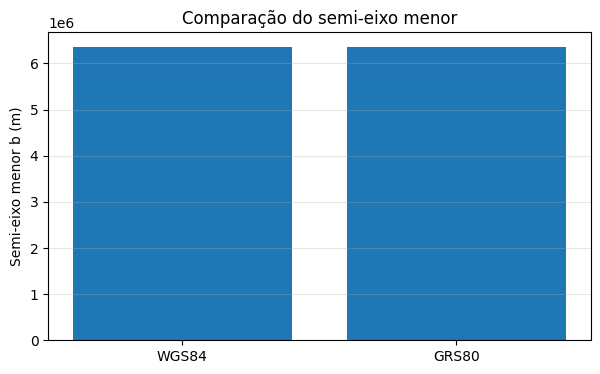

Diferença b(WGS84) - b(GRS80): 0.00010482314974069595 m


In [11]:
# ============================================================
# 7. GRÁFICO DO SEMI-EIXO MENOR
# ============================================================

nomes = ["WGS84", "GRS80"]
b_values = [wgs84.b, grs80.b]

plt.figure(figsize=(7, 4))
plt.bar(nomes, b_values)
plt.ylabel("Semi-eixo menor b (m)")
plt.title("Comparação do semi-eixo menor")
plt.grid(axis="y", alpha=0.3)
plt.show()

print("Diferença b(WGS84) - b(GRS80):", wgs84.b - grs80.b, "m")


## 8. Gráfico: achatamento dos elipsoides

O achatamento é um dos parâmetros fundamentais do elipsoide de referência.


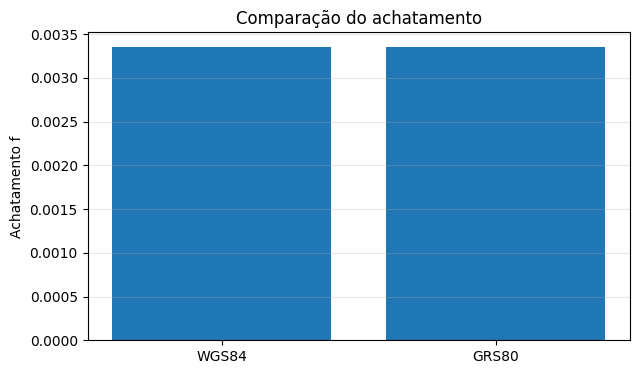

Diferença f(WGS84) - f(GRS80): -1.6434838299300703e-11


In [12]:
# ============================================================
# 8. GRÁFICO DO ACHATAMENTO
# ============================================================

f_values = [wgs84.f, grs80.f]

plt.figure(figsize=(7, 4))
plt.bar(nomes, f_values)
plt.ylabel("Achatamento f")
plt.title("Comparação do achatamento")
plt.grid(axis="y", alpha=0.3)
plt.show()

print("Diferença f(WGS84) - f(GRS80):", wgs84.f - grs80.f)


## 9. Gráfico: primeira excentricidade ao quadrado

A primeira excentricidade ao quadrado é usada em praticamente todas as transformações geodésicas.


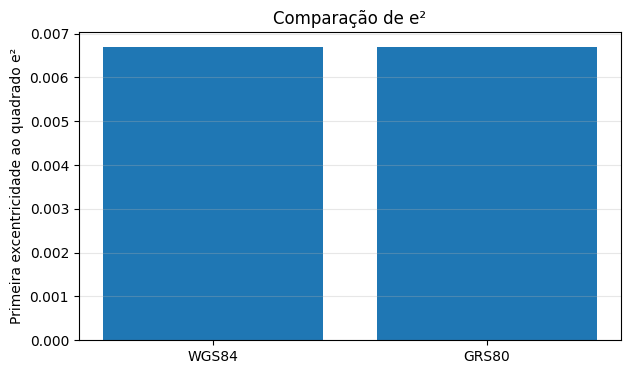

Diferença e²(WGS84) - e²(GRS80): -3.2759470483534336e-11


In [13]:
# ============================================================
# 9. GRÁFICO DA PRIMEIRA EXCENTRICIDADE AO QUADRADO
# ============================================================

e2_values = [wgs84.e2, grs80.e2]

plt.figure(figsize=(7, 4))
plt.bar(nomes, e2_values)
plt.ylabel("Primeira excentricidade ao quadrado e²")
plt.title("Comparação de e²")
plt.grid(axis="y", alpha=0.3)
plt.show()

print("Diferença e²(WGS84) - e²(GRS80):", wgs84.e2 - grs80.e2)


## 10. Conversão mGal para SI e SI para mGal

Na geodésia física e na gravimetria, é comum trabalhar com mGal. Aqui verificamos a conversão.


In [14]:
# ============================================================
# 10. CONVERSÕES mGal <-> SI
# ============================================================

anomalia_mgal = np.array([-50, -25, 0, 25, 50, 100], dtype=float)
anomalia_si = anomalia_mgal * constants.MGAL_TO_SI
anomalia_mgal_retorno = anomalia_si * constants.SI_TO_MGAL

print("Anomalia em mGal:")
print(anomalia_mgal)

print("\nAnomalia em SI m/s²:")
print(anomalia_si)

print("\nRetorno para mGal:")
print(anomalia_mgal_retorno)

print("\nErro de retorno:")
print(anomalia_mgal_retorno - anomalia_mgal)


Anomalia em mGal:
[-50. -25.   0.  25.  50. 100.]

Anomalia em SI m/s²:
[-0.0005  -0.00025  0.       0.00025  0.0005   0.001  ]

Retorno para mGal:
[-50. -25.   0.  25.  50. 100.]

Erro de retorno:
[0. 0. 0. 0. 0. 0.]


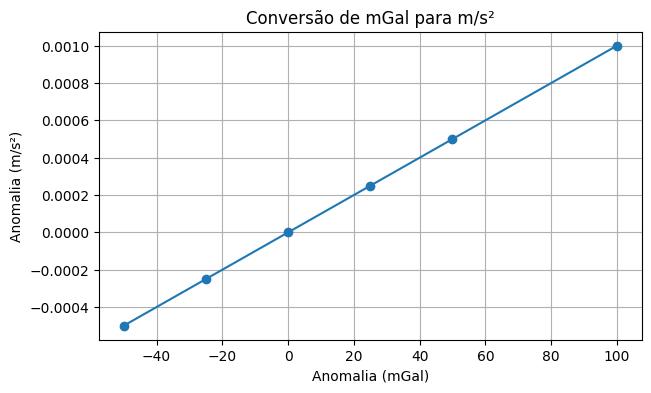

In [15]:
# Gráfico da conversão mGal -> SI
plt.figure(figsize=(7, 4))
plt.plot(anomalia_mgal, anomalia_si, marker="o")
plt.xlabel("Anomalia (mGal)")
plt.ylabel("Anomalia (m/s²)")
plt.title("Conversão de mGal para m/s²")
plt.grid(True)
plt.show()


## 11. Construindo um elipsoide personalizado

A classe `Ellipsoid` permite criar um elipsoide personalizado. Isso será útil posteriormente para comparar modelos ou testar elipsoides simplificados.


In [16]:
# ============================================================
# 11. ELIPSOIDE PERSONALIZADO
# ============================================================

custom = constants.Ellipsoid(
    name="SPHERE_TEST",
    a=6371000.0,
    f=0.0,
    GM=constants.WGS84_GM,
    omega=constants.WGS84_OMEGA
)

print(custom)

print("\nParâmetros derivados:")
print("b:", custom.b)
print("e²:", custom.e2)
print("e'²:", custom.ep2)


Ellipsoid(name='SPHERE_TEST', a=6371000.0, f=0.0, GM=398600441800000.0, omega=7.292115e-05)

Parâmetros derivados:
b: 6371000.0
e²: 0.0
e'²: 0.0


## 12. Comparação entre elipsoide e esfera

Aqui comparamos o WGS84 com uma esfera de raio médio aproximado.


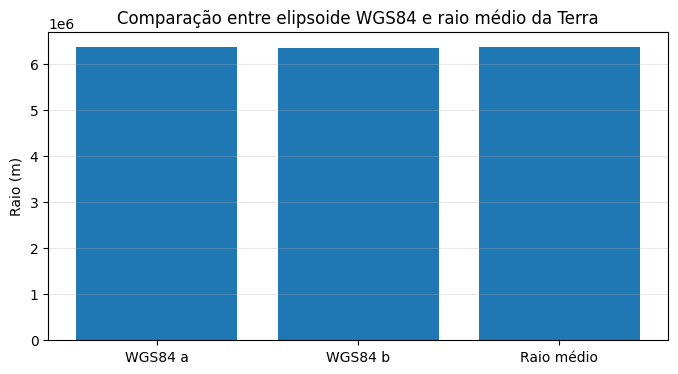

a - raio médio: 7128.200000000186
b - raio médio: -14256.485754820518


In [17]:
# ============================================================
# 12. COMPARAÇÃO WGS84 VS ESFERA
# ============================================================

modelos = ["WGS84 a", "WGS84 b", "Raio médio"]
valores = [wgs84.a, wgs84.b, constants.MEAN_EARTH_RADIUS]

plt.figure(figsize=(8, 4))
plt.bar(modelos, valores)
plt.ylabel("Raio (m)")
plt.title("Comparação entre elipsoide WGS84 e raio médio da Terra")
plt.grid(axis="y", alpha=0.3)
plt.show()

print("a - raio médio:", wgs84.a - constants.MEAN_EARTH_RADIUS)
print("b - raio médio:", wgs84.b - constants.MEAN_EARTH_RADIUS)


## 13. Resumo final do teste

Se todas as células anteriores foram executadas sem erro, o módulo `constants.py` está funcionando corretamente.

No próximo notebook, testaremos o módulo:

```python
geodesy/ellipsoid.py
```

com cálculos de semi-eixo menor, excentricidades, raios de curvatura, raio geocêntrico, latitude geocêntrica, latitude reduzida e gráficos em função da latitude.
